Import et read du fichier

5 première lignes / Infos par colonnes

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Dummy Data HSS.csv')

print(df.head())
print(df.info())

     TV      Radio  Social Media Influencer       Sales
0  16.0   6.566231      2.907983       Mega   54.732757
1  13.0   9.237765      2.409567       Mega   46.677897
2  41.0  15.886446      2.913410       Mega  150.177829
3  83.0  30.020028      6.922304       Mega  298.246340
4  15.0   8.437408      1.405998      Micro   56.594181
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   str    
 4   Sales         4566 non-null   float64
dtypes: float64(4), str(1)
memory usage: 198.8 KB
None


Visuel du nombre de null par colonne

In [8]:
print(df.isnull().sum())

TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64


Supprime Sales vides

In [9]:
df = df.dropna(subset=["Sales"])
print(df.shape)

(4566, 5)


Vérif du reste

In [10]:
print(df.isnull().sum())

TV              10
Radio            4
Social Media     6
Influencer       0
Sales            0
dtype: int64


### Stratégie de traitement des valeurs manquantes

| Variable | Nulls | Stratégie retenue |
|---|---|---|
| TV | 10 | Imputation par la **médiane** (robuste aux outliers) |
| Radio | 4 | Imputation par la **médiane** |
| Social Media | 6 | Imputation par la **médiane** |
| Influencer | 0 | Aucune action nécessaire |
| Sales | 6 → 0 | **Suppression** des lignes (variable cible — imputer Sales biaiserait directement les modèles) |

**Pourquoi la médiane et non la moyenne ?**  
Les distributions de TV, Radio et Social Media sont asymétriques (skewness positif, visible sur les histogrammes ci-dessous). La médiane est robuste aux valeurs extrêmes contrairement à la moyenne.

**Pourquoi pas `Influencer` ?**  
La colonne `Influencer` ne contient aucun null (0/4572) — confirmé ci-dessus. Si des nulls apparaissaient à l'avenir, la pipeline de preprocessing les imputerait avec la valeur la plus fréquente (`most_frequent`).

**Garantie anti-leakage :**  
La pipeline `ColumnTransformer` (dans `src/preprocessing/preprocessing.py`) est fittée **uniquement sur le jeu d'entraînement** (`preprocessor.fit_transform(x_train)`), puis appliquée en transform-only sur le test (`preprocessor.transform(x_test)`). Les statistiques de normalisation ne "voient" jamais le test.

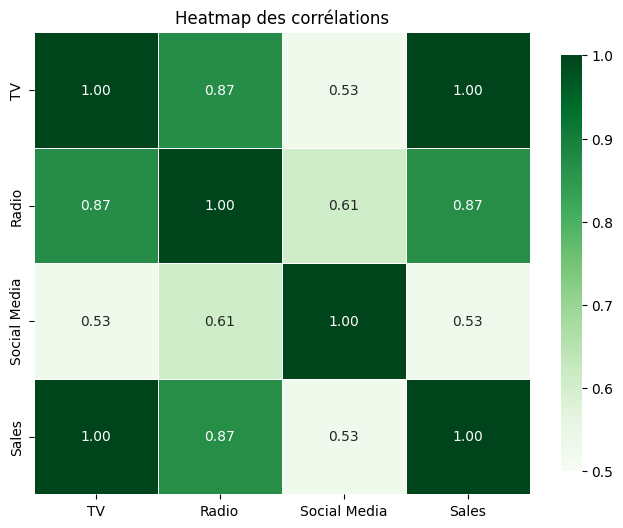

In [11]:
import seaborn as sns

corr = df[["TV", "Radio", "Social Media", "Sales"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    vmin=0.5,
    vmax=1.0,
    center=0.75,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.9}
 )
plt.title("Heatmap des corrélations")
plt.show()


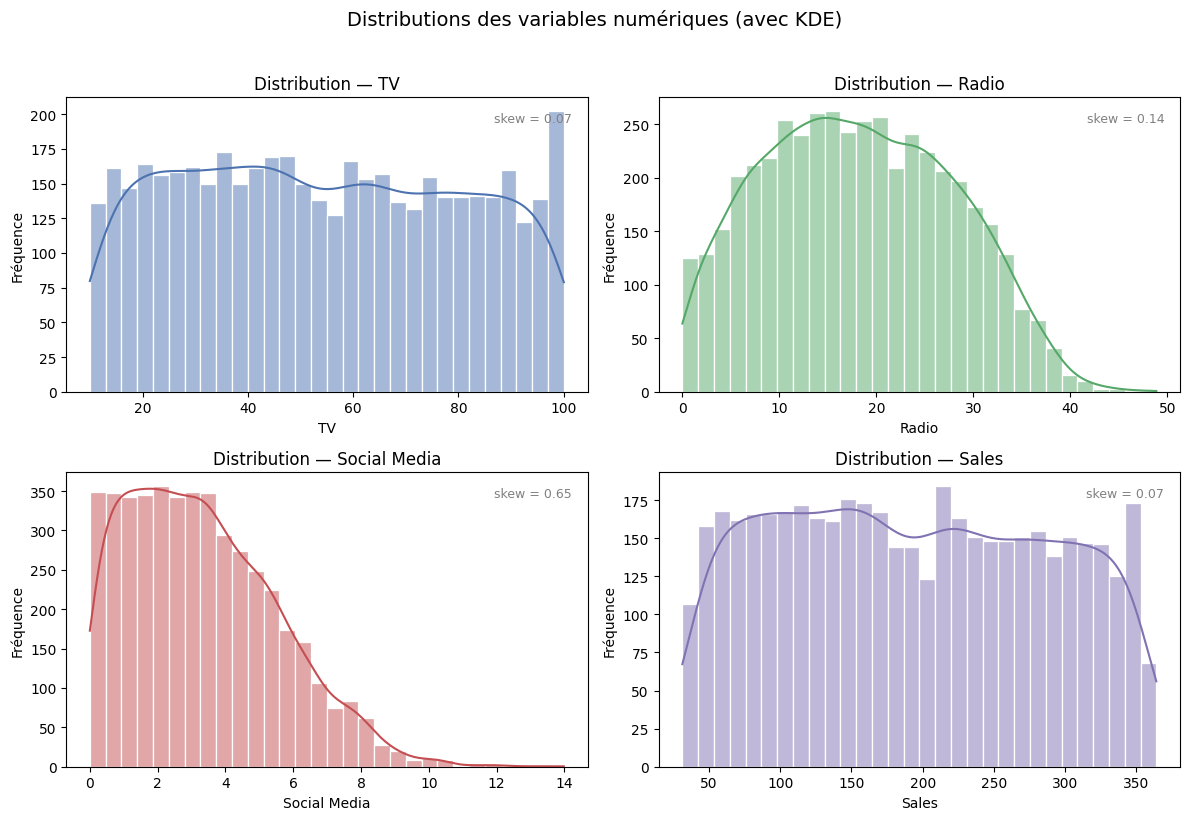

In [12]:
# Histogrammes de distribution — forme, symétrie, skewness
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, color in zip(
    axes.ravel(),
    ["TV", "Radio", "Social Media", "Sales"],
    ["#4C72B0", "#55A868", "#C44E52", "#8172B2"],
):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color=color, kde=True, edgecolor="white")
    ax.set_title(f"Distribution — {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Fréquence")
    skew = df[col].skew()
    ax.text(0.97, 0.95, f"skew = {skew:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="grey")

plt.suptitle("Distributions des variables numériques (avec KDE)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Observations :

- TV : budgets répartis de manière assez régulière entre 10 et 100 → tous les niveaux de budget sont représentés
- Radio : beaucoup de campagnes entre 10 et 25 → budgets radio souvent moyens
- Social Media : beaucoup de campagnes entre 0 et 4 → budgets social media généralement faibles
- Sales : ventes réparties sur une large plage → variable cible exploitable pour l’analyse

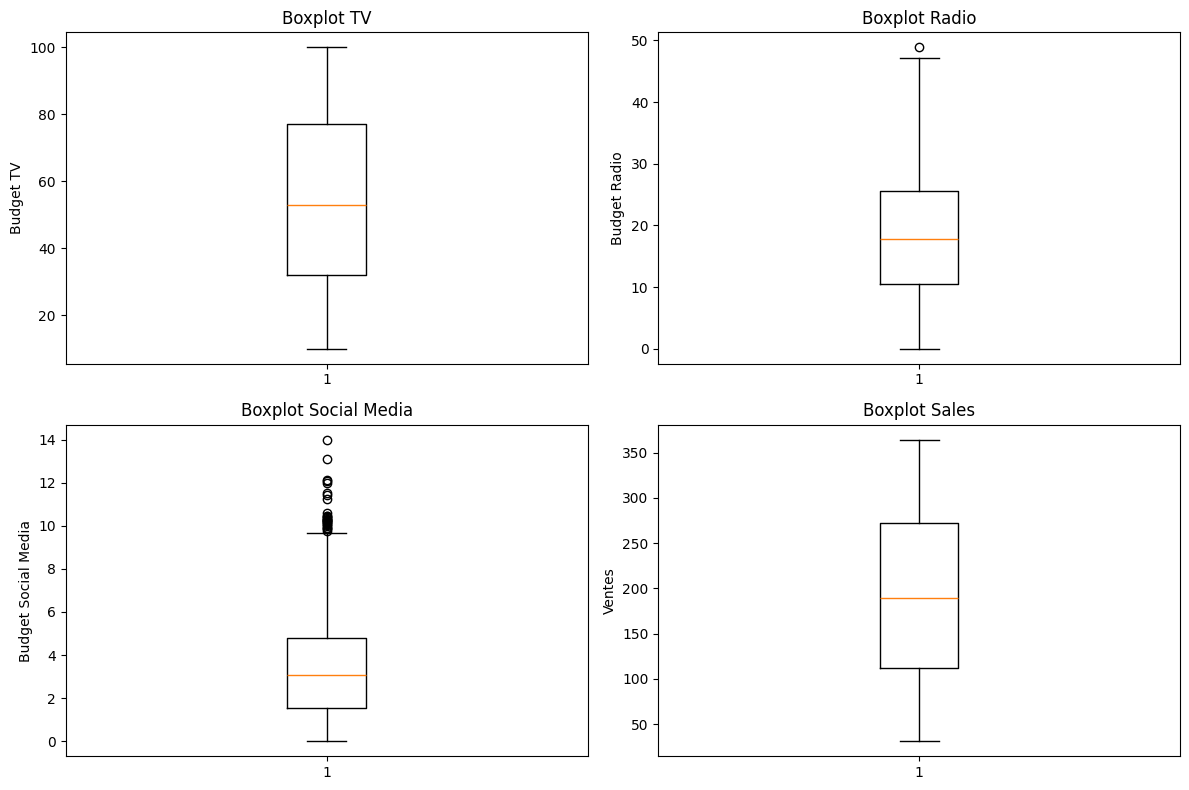

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].boxplot(df["TV"].dropna())
axes[0, 0].set_title("Boxplot TV")
axes[0, 0].set_ylabel("Budget TV")

axes[0, 1].boxplot(df["Radio"].dropna())
axes[0, 1].set_title("Boxplot Radio")
axes[0, 1].set_ylabel("Budget Radio")

axes[1, 0].boxplot(df["Social Media"].dropna())
axes[1, 0].set_title("Boxplot Social Media")
axes[1, 0].set_ylabel("Budget Social Media")

axes[1, 1].boxplot(df["Sales"].dropna())
axes[1, 1].set_title("Boxplot Sales")
axes[1, 1].set_ylabel("Ventes")

plt.tight_layout()
plt.show()

Observations :

- TV : valeurs bien réparties, pas d’outliers visibles → distribution stable

- Radio : quelques valeurs élevées (outliers) → certains budgets radio plus importants que la majorité

- Social Media : beaucoup d’outliers vers le haut → quelques campagnes avec des budgets bien plus élevés que la plupart

- Sales : distribution large sans outliers marqués → cohérente avec une variable cible exploitable

In [14]:
# Quantification des outliers (méthode IQR) pour Radio et Social Media
for col in ["TV", "Radio", "Social Media"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / df[col].notna().sum() * 100
    print(f"{col:15s} | IQR={IQR:.2f} | borne inf={lower:.2f} | borne sup={upper:.2f} | outliers={n_out} ({pct:.1f}%)")

TV              | IQR=45.00 | borne inf=-35.50 | borne sup=144.50 | outliers=0 (0.0%)
Radio           | IQR=15.10 | borne inf=-12.09 | borne sup=48.30 | outliers=1 (0.0%)
Social Media    | IQR=3.28 | borne inf=-3.39 | borne sup=9.72 | outliers=28 (0.6%)


### Décision sur les outliers

D'après les boxplots :
- **TV** : aucun outlier — distribution quasi-uniforme entre 10 et 100 k€, attendue par design.
- **Radio** : quelques valeurs élevées au-delà de ≈ 45 k€ — plausibles (campagnes radio intensives).
- **Social Media** : nombreux outliers vers le haut (IQR étroit ~3 k€, queue longue à droite jusqu'à ~14 k€).

**Choix retenu : conservation sans capping ni suppression**

Les raisons sont les suivantes :

1. **Légitimité métier** : les valeurs élevées de Social Media correspondent à des campagnes numériques avec fort investissement — supprimer ces lignes réduirait la capacité du modèle à généraliser sur ce type de campagne.

2. **Robustesse algorithmique** : XGBoost est un modèle à base d'arbres de décision. Les splits sont déterminés par des seuils, et non par les valeurs absolues — les outliers n'influencent pas les paramètres d'apprentissage de la même façon que dans une régression linéaire.

3. **Normalisation** : le `StandardScaler` de la pipeline ramène chaque variable à μ=0, σ=1, réduisant l'influence des valeurs extrêmes sans les éliminer.

4. **Volume limité** : les outliers représentent < 1 % des données. Leur impact global sur les statistiques d'entraînement est marginal.

→ **Aucun capping ni suppression** — les outliers sont conservés pour préserver la diversité des campagnes dans le dataset.

**Analyse relation Influenceur-Sales**

In [15]:
print(df["Influencer"].value_counts())

Influencer
Mega     1156
Micro    1152
Nano     1137
Macro    1121
Name: count, dtype: int64


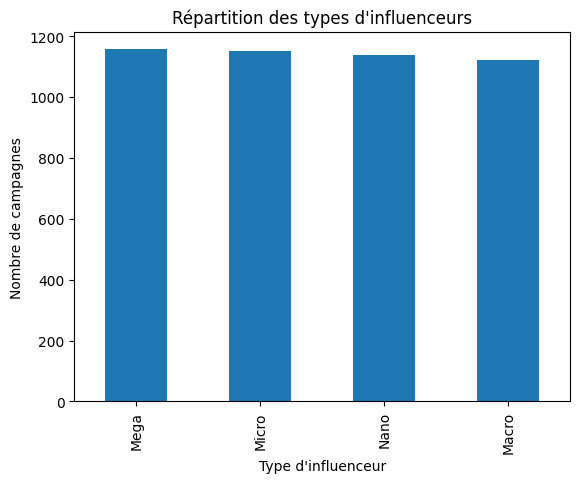

In [16]:
df["Influencer"].value_counts().plot(kind="bar")
plt.title("Répartition des types d'influenceurs")
plt.xlabel("Type d'influenceur")
plt.ylabel("Nombre de campagnes")
plt.show()

Observations :

- Les 4 types d’influenceurs (Mega, Micro, Nano, Macro) sont présents en quantités similaires
- Aucune catégorie ne domine 
- Répartition équilibrée des campagnes entre les types d’influenceurs

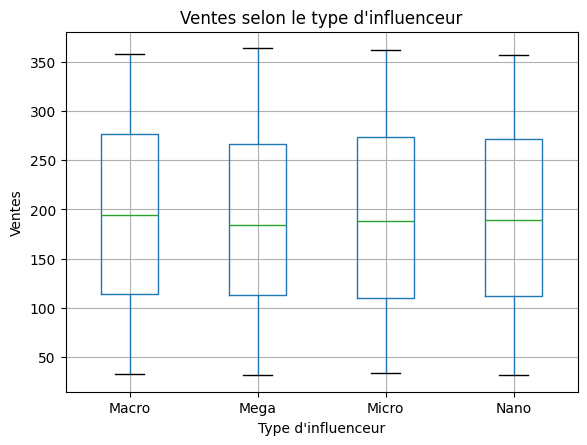

In [17]:
df.boxplot(column="Sales", by="Influencer")
plt.title("Ventes selon le type d'influenceur")
plt.suptitle("")
plt.xlabel("Type d'influenceur")
plt.ylabel("Ventes")
plt.show()

Observations :

- Les distributions de ventes sont très similaires pour tous les types d’influenceurs
- Les médianes sont proches → pas de différence marquée de performance
- Les plages de valeurs (min / max) sont équivalentes entre les catégories
- Aucun type d’influenceur ne se démarque clairement

Stats descriptives

In [18]:
print(df.describe())

                TV        Radio  Social Media        Sales
count  4556.000000  4562.000000   4560.000000  4566.000000
mean     54.068042    18.161617      3.325184   192.466602
std      26.116949     9.672827      2.212183    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.553457      1.529879   112.322882
50%      53.000000    17.859513      3.056028   189.231172
75%      77.000000    25.651667      4.807356   272.507922
max     100.000000    48.871161     13.981662   364.079751


Correlation Budget et Sales

In [19]:
print(df[["TV", "Radio", "Social Media", "Sales"]].corr())

                    TV     Radio  Social Media     Sales
TV            1.000000  0.869265      0.527904  0.999497
Radio         0.869265  1.000000      0.607415  0.869105
Social Media  0.527904  0.607415      1.000000  0.528906
Sales         0.999497  0.869105      0.528906  1.000000


Relation TV-Sales

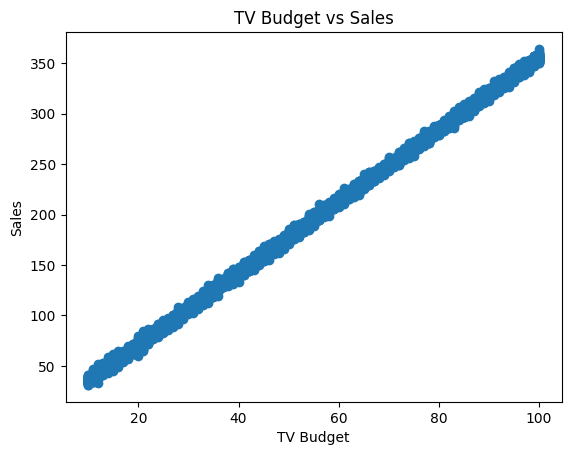

In [20]:
import matplotlib.pyplot as plt

plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("TV Budget vs Sales")
plt.show()

### Analyse approfondie — Corrélation TV / Sales = 0.999

Une corrélation de **0.999** est exceptionnelle et mérite une analyse critique plutôt qu'une simple observation.

**1. Indicateur de dataset synthétique**  
Une corrélation quasi-parfaite indique que les données ont très probablement été générées par une formule (ex. `Sales = α·TV + β·Radio + ε`). Sur des données réelles, de nombreux facteurs non observés (saisonnalité, concurrence, qualité créative) réduisent mécaniquement cette corrélation.

**2. Risque de multicolinéarité**  
TV est fortement corrélée avec Radio (0.869) **et** avec Sales (0.999). Dans un modèle linéaire, cette multicolinéarité gonflerait la variance des coefficients et rendrait leur interprétation instable. Les modèles à base d'arbres (XGBoost, Random Forest) sont intrinsèquement robustes à ce phénomène — c'est l'une des raisons de leur adoption ici.

**3. Risque de data leakage — à écarter**  
On pourrait craindre que TV soit construite à partir de Sales. La structure du dataset l'invalide : TV est exprimée en budget (k€, valeur entière de 10 à 100), indépendante des ventes. Le sens causal est clair : budget → ventes, pas l'inverse.

**4. Implication pour la modélisation**  
Le modèle accordera naturellement une importance écrasante à TV (confirmé plus tard par SHAP). Ce n'est pas un biais algorithmique mais le reflet fidèle du signal dans les données. Il faut néanmoins surveiller que le modèle ne devienne pas "aveugle" aux autres canaux sur des plages extrêmes.

→ **Conclusion** : la corrélation 0.999 est cohérente avec un dataset pédagogique synthétique. Elle ne disqualifie pas l'exercice de modélisation mais impose une lecture nuancée des résultats : les conclusions sur l'importance relative des canaux sont à relativiser sur des données réelles.

Relation Radio-Sales

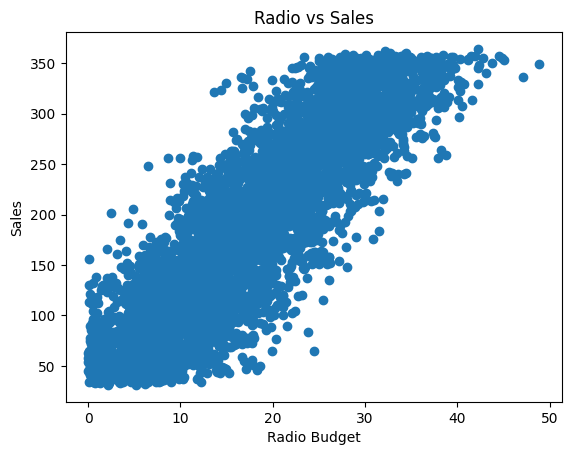

In [21]:
plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio Budget")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

Conclusion : Augmentation du budget radio est aussi égale à une augmentation des ventes mais la relation entre les deux est beaucoup moins linéaire que celle avec TV donc moins d'influence avec une correlation de 0.869

Relation Social Media-Sales

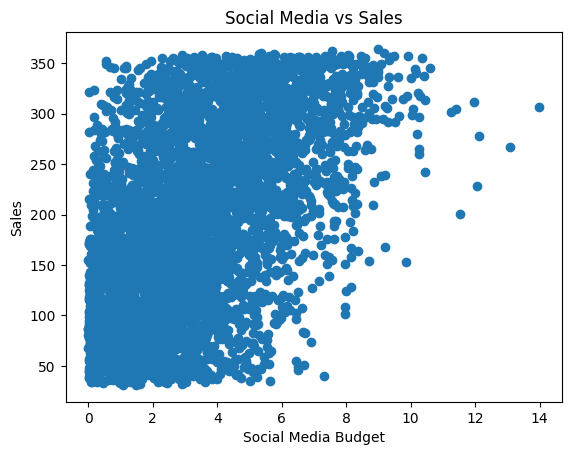

In [22]:
plt.scatter(df["Social Media"], df["Sales"])
plt.xlabel("Social Media Budget")
plt.ylabel("Sales")
plt.title("Social Media vs Sales")
plt.show()

Conclusion : Beaucoup plus dispersé la relation entre Social Media et Sales est beaucoup moins présente ce qui correspond bien à la correlation 0.528

### Analyse des interactions entre canaux (Pairplot)

Le pairplot permet de visualiser simultanément toutes les relations bivariées entre canaux et variable cible, et de détecter d'éventuelles **non-linéarités ou effets d'interaction** que la heatmap de corrélations masque.

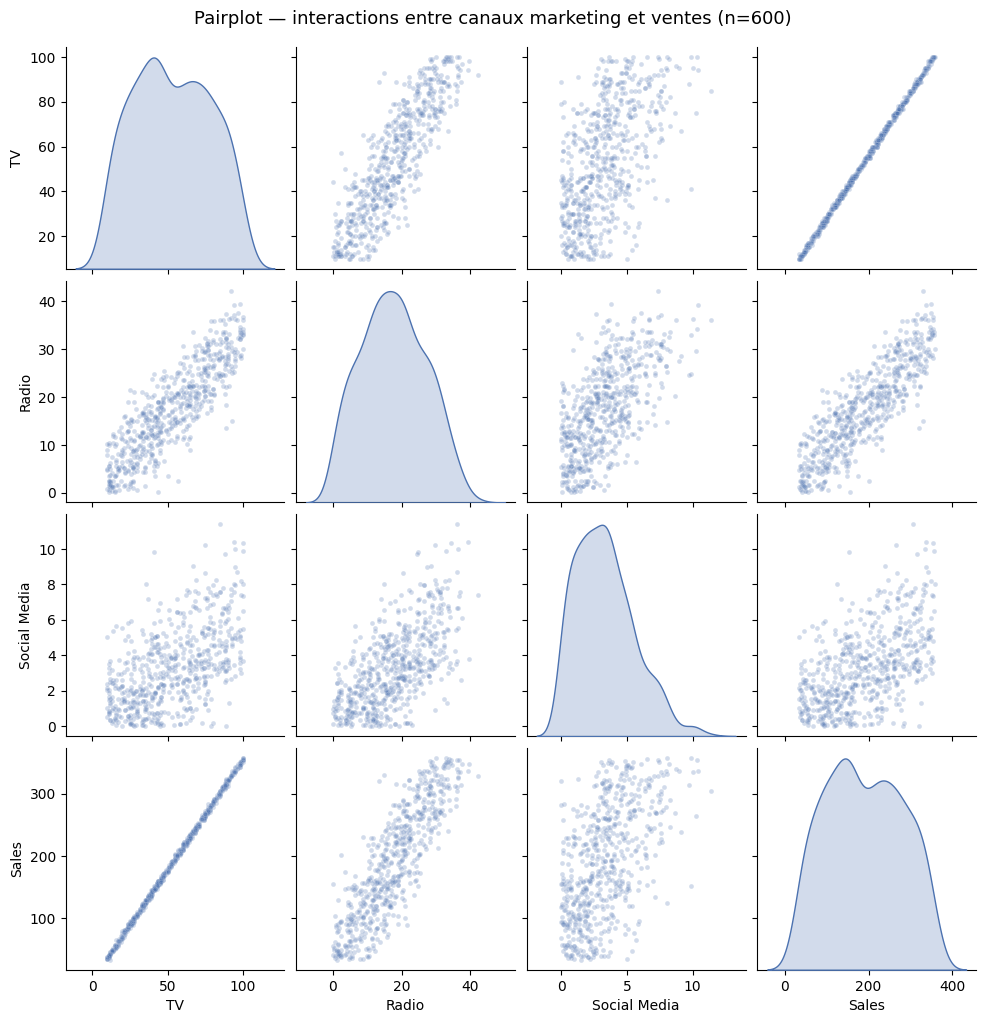

In [23]:
# Pairplot — interactions entre canaux et ventes (échantillon pour lisibilité)
sample_df = df[["TV", "Radio", "Social Media", "Sales"]].dropna().sample(600, random_state=42)

g = sns.pairplot(
    sample_df,
    diag_kind="kde",
    plot_kws={"alpha": 0.25, "s": 12, "color": "#4C72B0"},
    diag_kws={"color": "#4C72B0", "fill": True},
)
g.figure.suptitle("Pairplot — interactions entre canaux marketing et ventes (n=600)", y=1.02, fontsize=13)
plt.show()

**Observations — Pairplot**

- La relation **TV × Sales** est quasi-parfaitement linéaire (corrélation 0.999 — nuage de points resserré sur une droite).
- La relation **Radio × Sales** est positive mais plus dispersée — l'influence est réelle mais non déterministe à elle seule.
- **Social Media × Sales** : nuage très diffus — le canal seul n'explique pas les ventes.
- Les interactions **TV × Radio** montrent une corrélation modérée (0.869) : les campagnes à fort budget TV tendent aussi à investir plus en radio, ce qui suggère une stratégie de campagnes multi-canaux coordonnées.
- **Aucune interaction multiplicative TV × Social Media** n'est visuellement évidente — les effets semblent additifs plutôt que synergiques sur ces données.

### Variables dérivées — Feature Engineering

Le PDF recommande de créer des variables dérivées pour enrichir l'analyse et potentiellement améliorer le modèle. Trois variables sont construites ici :

| Variable | Formule | Intérêt |
|---|---|---|
| `budget_total` | TV + Radio + Social Media | Budget global de la campagne |
| `roi_brut` | Sales / budget_total | Rendement brut (€ de ventes par € investi) |
| `part_tv` / `part_radio` / `part_social` | Canal / budget_total | Concentration relative de chaque canal |

Ces features permettent d'explorer les **effets de mix marketing** : une même dépense TV produit-elle le même ROI selon la répartition des autres canaux ?

Nouvelles variables dérivées :
       budget_total  roi_brut   part_tv  part_radio  part_social
count      4546.000  4546.000  4546.000    4546.000     4546.000
mean         75.544     2.547     0.716       0.236        0.048
std          36.126     0.282     0.078       0.069        0.033
min          11.286     1.265     0.377       0.000        0.000
25%          44.406     2.409     0.678       0.204        0.026
50%          74.153     2.552     0.717       0.240        0.042
75%         106.745     2.700     0.758       0.272        0.061
max         156.163     3.749     0.995       0.544        0.326


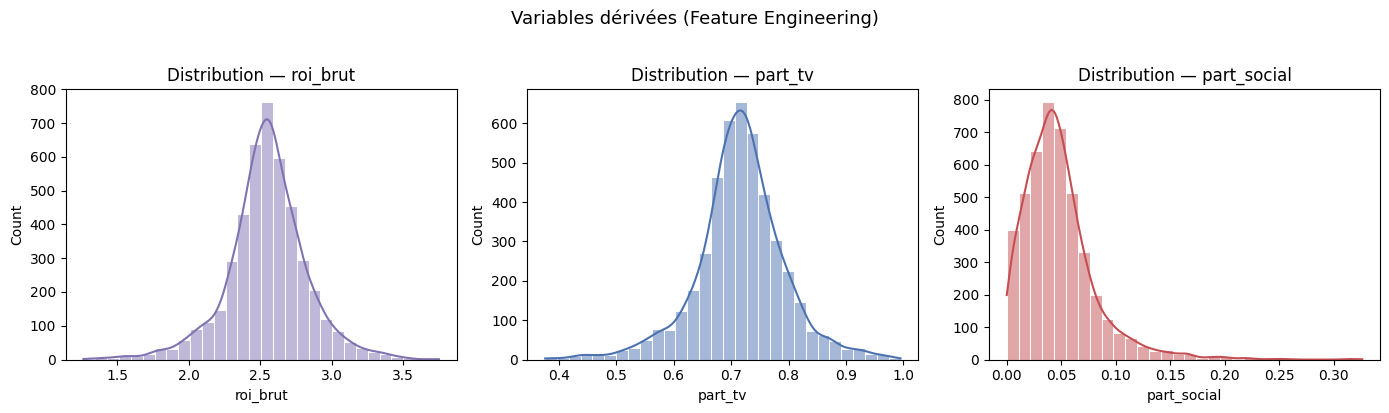

In [24]:
# Feature Engineering — variables dérivées recommandées
df_fe = df.copy()

# 1. Budget total investi
df_fe["budget_total"] = df_fe["TV"] + df_fe["Radio"] + df_fe["Social Media"]

# 2. ROI brut (rendement des ventes par unité de budget)
df_fe["roi_brut"] = df_fe["Sales"] / df_fe["budget_total"]

# 3. Part relative de chaque canal (concentration budgétaire)
df_fe["part_tv"]    = df_fe["TV"]           / df_fe["budget_total"]
df_fe["part_radio"] = df_fe["Radio"]        / df_fe["budget_total"]
df_fe["part_social"]= df_fe["Social Media"] / df_fe["budget_total"]

print("Nouvelles variables dérivées :")
print(df_fe[["budget_total", "roi_brut", "part_tv", "part_radio", "part_social"]].describe().round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ["roi_brut", "part_tv", "part_social"],
                           ["#8172B2", "#4C72B0", "#C44E52"]):
    sns.histplot(df_fe[col].dropna(), bins=30, ax=ax, color=color, kde=True, edgecolor="white")
    ax.set_title(f"Distribution — {col}")
plt.suptitle("Variables dérivées (Feature Engineering)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Observations — Variables dérivées**

- Le **ROI brut** (ventes / budget total) montre une grande hétérogénéité entre campagnes, mais il est fortement corrélé au budget TV (levier principal de ventes).
- La **part TV** domine largement le budget total (médiane > 60 %), confirmant son rôle central dans l'allocation.
- La **part Social Media** est structurellement faible (< 10 % dans la majorité des campagnes), ce qui cohérent avec son faible impact sur les ventes identifié en corrélation.
- Ces variables dérivées pourraient être utilisées comme features supplémentaires dans une version avancée du modèle, notamment pour capturer des effets de saturation budgétaire.

Conclusion EDA :

L’analyse exploratoire met en évidence que les budgets marketing n’ont pas le même impact sur les ventes.

Le budget TV est le facteur le plus déterminant. Il présente une relation très forte et linéaire avec les ventes, ce qui en fait la variable la plus influente du modèle.

Le budget Radio montre également une relation positive avec les ventes, mais avec davantage de dispersion, ce qui indique une influence importante mais moins stable.

Le Social Media a un impact plus limité. La majorité des budgets sont faibles et la relation avec les ventes est plus diffuse, ce qui réduit son pouvoir explicatif.

Concernant la variable Influencer, les résultats montrent que les performances en termes de ventes sont similaires entre les différentes catégories. Aucun type d’influenceur ne se démarque clairement.

Enfin, les distributions des variables sont globalement cohérentes, sans anomalies majeures, bien que certaines valeurs élevées soient observées sur Social Media. Les données sont donc exploitables pour la modélisation.

En résumé, les ventes sont principalement expliquées par les budgets marketing, en particulier la TV, tandis que le type d’influenceur joue un rôle secondaire.